# Hospital Patient Records: Statistical & Healthcare Operations Analysis

**Project objective:** Use Python to evaluate data quality, healthcare utilization, encounter duration, payer coverage, procedure cost, and repeat utilization using synthetic hospital patient records.

**Analytical principle:** Findings are separated from interpretation. Statistical association is not treated as causation, and the project-defined 30-day repeat encounter metric is not presented as a formal clinical readmission rate.


# 1. Business Problem 

Healthcare organizations need reliable visibility into patient utilization, encounter mix, cost, payer coverage, procedure activity, and repeat encounters. This analysis evaluates those areas while first validating whether the underlying data are suitable for analysis.

### Business questions
- How has encounter volume changed over time?
- What types of encounters make up overall utilization?
- How long do encounters last, and how skewed is the duration distribution?
- Does zero recorded payer coverage vary by encounter class?
- Which procedures are most frequent, most expensive on average, and largest in total cost impact?
- How do claim costs and coverage vary across payers?
- How many unique patients have inpatient encounters each quarter?
- How frequently do patients return within 30 days of a prior encounter?
- Which patients show the highest utilization?

# 2. Data Source

This project uses the **Maven Analytics Hospital Patient Records** synthetic dataset, based on Synthea-generated electronic health record data. The analysis uses:

- `encounters.csv`
- `patients.csv`
- `procedures.csv`
- `payers.csv`

The records are synthetic and are intended for analytical and educational use rather than clinical decision-making or evaluation of real patients, providers, or payers.

**Citation supplied with the dataset:** Walonoski, J. et al. (2018). *Synthea: An approach, method, and software mechanism for generating synthetic patients and the synthetic electronic health care record.* Journal of the American Medical Informatics Association, 25(3), 230–238.


## Setup

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# Resolve data whether notebook is run from the project notebooks/ folder
# or from the same folder as the CSV files.
CANDIDATE_DIRS = [Path("../data"), Path("data"), Path("."), Path("/mnt/data")]

def resolve_file(filename):
    for folder in CANDIDATE_DIRS:
        path = folder / filename
        if path.exists():
            return path
    raise FileNotFoundError(f"Could not find {filename}. Checked: {CANDIDATE_DIRS}")

encounters_path = resolve_file("encounters.csv")
patients_path = resolve_file("patients.csv")
procedures_path = resolve_file("procedures.csv")
payers_path = resolve_file("payers.csv")

encounters = pd.read_csv(encounters_path)
patients = pd.read_csv(patients_path)
procedures = pd.read_csv(procedures_path)
payers = pd.read_csv(payers_path)

print("Loaded files:")
print(" encounters:", encounters_path)
print(" patients:  ", patients_path)
print(" procedures:", procedures_path)
print(" payers:    ", payers_path)

Loaded files:
 encounters: ..\data\encounters.csv
 patients:   ..\data\patients.csv
 procedures: ..\data\procedures.csv
 payers:     ..\data\payers.csv


# 3. Data Understanding

This section describes the raw tables before analytical transformations.

### 3.1 Dataset dimensions

In [2]:
dataset_dimensions = pd.DataFrame({
    "dataset": ["encounters", "patients", "procedures", "payers"],
    "rows": [len(encounters), len(patients), len(procedures), len(payers)],
    "columns": [encounters.shape[1], patients.shape[1], procedures.shape[1], payers.shape[1]]
})
display(dataset_dimensions)

,dataset,rows,columns
0,encounters,27891,14
1,patients,974,20
2,procedures,47701,9
3,payers,10,7


### 3.2 Columns

In [3]:
for name, df in {
    "encounters": encounters,
    "patients": patients,
    "procedures": procedures,
    "payers": payers
}.items():
    print(f"\n{name.upper()} COLUMNS")
    print(df.columns.tolist())


ENCOUNTERS COLUMNS
['Id', 'START', 'STOP', 'PATIENT', 'ORGANIZATION', 'PAYER', 'ENCOUNTERCLASS', 'CODE', 'DESCRIPTION', 'BASE_ENCOUNTER_COST', 'TOTAL_CLAIM_COST', 'PAYER_COVERAGE', 'REASONCODE', 'REASONDESCRIPTION']

PATIENTS COLUMNS
['Id', 'BIRTHDATE', 'DEATHDATE', 'PREFIX', 'FIRST', 'LAST', 'SUFFIX', 'MAIDEN', 'MARITAL', 'RACE', 'ETHNICITY', 'GENDER', 'BIRTHPLACE', 'ADDRESS', 'CITY', 'STATE', 'COUNTY', 'ZIP', 'LAT', 'LON']

PROCEDURES COLUMNS
['START', 'STOP', 'PATIENT', 'ENCOUNTER', 'CODE', 'DESCRIPTION', 'BASE_COST', 'REASONCODE', 'REASONDESCRIPTION']

PAYERS COLUMNS
['Id', 'NAME', 'ADDRESS', 'CITY', 'STATE_HEADQUARTERED', 'ZIP', 'PHONE']


### 3.3 Data types

In [4]:
for name, df in {
    "encounters": encounters,
    "patients": patients,
    "procedures": procedures,
    "payers": payers
}.items():
    print(f"\n{name.upper()} DATA TYPES")
    display(df.dtypes.rename("dtype").to_frame())


ENCOUNTERS DATA TYPES


,dtype
Id,str
START,str
STOP,str
PATIENT,str
ORGANIZATION,str
PAYER,str
ENCOUNTERCLASS,str
CODE,int64
DESCRIPTION,str
BASE_ENCOUNTER_COST,float64



PATIENTS DATA TYPES


,dtype
Id,str
BIRTHDATE,str
DEATHDATE,str
PREFIX,str
FIRST,str
LAST,str
SUFFIX,str
MAIDEN,str
MARITAL,str
RACE,str



PROCEDURES DATA TYPES


,dtype
START,str
STOP,str
PATIENT,str
ENCOUNTER,str
CODE,int64
DESCRIPTION,str
BASE_COST,int64
REASONCODE,float64
REASONDESCRIPTION,str



PAYERS DATA TYPES


,dtype
Id,str
NAME,str
ADDRESS,str
CITY,str
STATE_HEADQUARTERED,str
ZIP,float64
PHONE,str


### 3.4 Missing values

In [5]:
def missing_summary(df):
    out = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2)
    })
    return out.sort_values(["missing_count", "missing_pct"], ascending=False)

for name, df in {
    "encounters": encounters,
    "patients": patients,
    "procedures": procedures,
    "payers": payers
}.items():
    print(f"\n{name.upper()} MISSING VALUES")
    display(missing_summary(df))


ENCOUNTERS MISSING VALUES


,missing_count,missing_pct
REASONCODE,19541,70.06
REASONDESCRIPTION,19541,70.06
Id,0,0.00
START,0,0.00
STOP,0,0.00
PATIENT,0,0.00
ORGANIZATION,0,0.00
PAYER,0,0.00
ENCOUNTERCLASS,0,0.00
CODE,0,0.00



PATIENTS MISSING VALUES


,missing_count,missing_pct
SUFFIX,953,97.84
DEATHDATE,820,84.19
MAIDEN,588,60.37
ZIP,142,14.58
MARITAL,1,0.10
Id,0,0.00
BIRTHDATE,0,0.00
PREFIX,0,0.00
FIRST,0,0.00
LAST,0,0.00



PROCEDURES MISSING VALUES


,missing_count,missing_pct
REASONCODE,36945,77.45
REASONDESCRIPTION,36945,77.45
START,0,0.00
STOP,0,0.00
PATIENT,0,0.00
ENCOUNTER,0,0.00
CODE,0,0.00
DESCRIPTION,0,0.00
BASE_COST,0,0.00



PAYERS MISSING VALUES


,missing_count,missing_pct
ADDRESS,1,10.00
CITY,1,10.00
STATE_HEADQUARTERED,1,10.00
ZIP,1,10.00
PHONE,1,10.00
Id,0,0.00
NAME,0,0.00


**Interpretation note:** Missingness is not automatically an error. For example, `DEATHDATE`, `MAIDEN`, `SUFFIX`, and reason fields may legitimately be blank depending on the record. The purpose here is to identify missingness before deciding whether action is required.

### 3.5 Unique values

In [6]:
unique_summary = pd.DataFrame({
    "metric": [
        "Unique encounter IDs",
        "Unique patients in encounters",
        "Unique payer IDs in encounters",
        "Encounter classes",
        "Unique patient IDs in patient table",
        "Unique procedure descriptions",
        "Unique payer records"
    ],
    "value": [
        encounters["Id"].nunique(),
        encounters["PATIENT"].nunique(),
        encounters["PAYER"].nunique(),
        encounters["ENCOUNTERCLASS"].nunique(),
        patients["Id"].nunique(),
        procedures["DESCRIPTION"].nunique(),
        payers["Id"].nunique()
    ]
})
display(unique_summary)

print("Encounter classes:", sorted(encounters["ENCOUNTERCLASS"].dropna().unique()))

,metric,value
0,Unique encounter IDs,27891
1,Unique patients in encounters,974
2,Unique payer IDs in encounters,10
3,Encounter classes,6
4,Unique patient IDs in patient table,974
5,Unique procedure descriptions,163
6,Unique payer records,10


Encounter classes: ['ambulatory', 'emergency', 'inpatient', 'outpatient', 'urgentcare', 'wellness']


# 4. Data Quality Assessment

The goal is to identify quality risks **before** transforming the working data. Temporary parsed date series are used for validation so the raw dataframes remain unchanged.

In [7]:
start_check = pd.to_datetime(encounters["START"], errors="coerce", utc=True)
stop_check = pd.to_datetime(encounters["STOP"], errors="coerce", utc=True)
procedure_start_check = pd.to_datetime(procedures["START"], errors="coerce", utc=True)
procedure_stop_check = pd.to_datetime(procedures["STOP"], errors="coerce", utc=True)

### 4.1 Duplicates

In [8]:
duplicate_checks = pd.DataFrame({
    "check": [
        "Duplicate encounter rows",
        "Duplicate encounter IDs",
        "Duplicate patient rows",
        "Duplicate patient IDs",
        "Duplicate procedure rows",
        "Duplicate payer rows",
        "Duplicate payer IDs"
    ],
    "count": [
        encounters.duplicated().sum(),
        encounters["Id"].duplicated().sum(),
        patients.duplicated().sum(),
        patients["Id"].duplicated().sum(),
        procedures.duplicated().sum(),
        payers.duplicated().sum(),
        payers["Id"].duplicated().sum()
    ]
})
display(duplicate_checks)

,check,count
0,Duplicate encounter rows,0
1,Duplicate encounter IDs,0
2,Duplicate patient rows,0
3,Duplicate patient IDs,0
4,Duplicate procedure rows,0
5,Duplicate payer rows,0
6,Duplicate payer IDs,0


### 4.2 Missing values

In [9]:
critical_missing = pd.DataFrame({
    "field": ["Encounter Id", "START", "STOP", "PATIENT", "PAYER", "TOTAL_CLAIM_COST", "PAYER_COVERAGE"],
    "missing_count": [
        encounters["Id"].isna().sum(),
        start_check.isna().sum(),
        stop_check.isna().sum(),
        encounters["PATIENT"].isna().sum(),
        encounters["PAYER"].isna().sum(),
        encounters["TOTAL_CLAIM_COST"].isna().sum(),
        encounters["PAYER_COVERAGE"].isna().sum()
    ]
})
display(critical_missing)

,field,missing_count
0,Encounter Id,0
1,START,0
2,STOP,0
3,PATIENT,0
4,PAYER,0
5,TOTAL_CLAIM_COST,0
6,PAYER_COVERAGE,0


### 4.3 Invalid dates

In [10]:
invalid_date_checks = pd.DataFrame({
    "check": [
        "Invalid/missing encounter START",
        "Invalid/missing encounter STOP",
        "Encounter STOP before START",
        "Invalid/missing procedure START",
        "Invalid/missing procedure STOP",
        "Procedure STOP before START"
    ],
    "count": [
        start_check.isna().sum(),
        stop_check.isna().sum(),
        (stop_check < start_check).sum(),
        procedure_start_check.isna().sum(),
        procedure_stop_check.isna().sum(),
        (procedure_stop_check < procedure_start_check).sum()
    ]
})
display(invalid_date_checks)

,check,count
0,Invalid/missing encounter START,0
1,Invalid/missing encounter STOP,0
2,Encounter STOP before START,0
3,Invalid/missing procedure START,0
4,Invalid/missing procedure STOP,0
5,Procedure STOP before START,0


### 4.4 Negative costs

In [11]:
negative_cost_checks = pd.DataFrame({
    "check": [
        "Negative base encounter cost",
        "Negative total claim cost",
        "Negative payer coverage",
        "Negative procedure base cost"
    ],
    "count": [
        (encounters["BASE_ENCOUNTER_COST"] < 0).sum(),
        (encounters["TOTAL_CLAIM_COST"] < 0).sum(),
        (encounters["PAYER_COVERAGE"] < 0).sum(),
        (procedures["BASE_COST"] < 0).sum()
    ]
})
display(negative_cost_checks)

,check,count
0,Negative base encounter cost,0
1,Negative total claim cost,0
2,Negative payer coverage,0
3,Negative procedure base cost,0


### 4.5 Invalid payer coverage

In [12]:
payer_coverage_checks = pd.DataFrame({
    "check": [
        "Zero recorded payer coverage",
        "Coverage greater than total claim cost",
        "Encounter payer IDs missing from payer table"
    ],
    "count": [
        (encounters["PAYER_COVERAGE"] == 0).sum(),
        (encounters["PAYER_COVERAGE"] > encounters["TOTAL_CLAIM_COST"]).sum(),
        len(set(encounters["PAYER"].dropna()) - set(payers["Id"].dropna()))
    ]
})
payer_coverage_checks["pct_of_encounters"] = [
    (encounters["PAYER_COVERAGE"] == 0).mean() * 100,
    (encounters["PAYER_COVERAGE"] > encounters["TOTAL_CLAIM_COST"]).mean() * 100,
    np.nan
]
display(payer_coverage_checks)

,check,count,pct_of_encounters
0,Zero recorded payer coverage,13586,48.71
1,Coverage greater than total claim cost,0,0.00
2,Encounter payer IDs missing from payer table,0,NaN


### 4.6 Duration anomalies

In [13]:
duration_check = (stop_check - start_check).dt.total_seconds() / 3600

duration_quality = pd.Series({
    "minimum_hours": duration_check.min(),
    "median_hours": duration_check.median(),
    "mean_hours": duration_check.mean(),
    "p90_hours": duration_check.quantile(0.90),
    "p95_hours": duration_check.quantile(0.95),
    "p99_hours": duration_check.quantile(0.99),
    "maximum_hours": duration_check.max(),
    "negative_duration_count": (duration_check < 0).sum(),
    "exactly_24_hours_count": (duration_check == 24).sum(),
    "greater_than_24_hours_count": (duration_check > 24).sum()
})
display(duration_quality.to_frame("value"))

,value
minimum_hours,0.25
median_hours,0.25
mean_hours,7.27
p90_hours,2.80
p95_hours,3.80
p99_hours,24.00
maximum_hours,"44,930.00"
negative_duration_count,0.00
exactly_24_hours_count,"1,077.00"
greater_than_24_hours_count,75.00


**Decision:** Extreme duration values are flagged and retained rather than automatically deleted. The distribution is highly skewed, so medians and percentiles are emphasized. Exactly 24-hour encounters are reported separately from encounters longer than 24 hours.

### 4.7 Referential integrity

In [14]:
referential_integrity = pd.DataFrame({
    "relationship": [
        "encounters.PATIENT -> patients.Id",
        "encounters.PAYER -> payers.Id",
        "procedures.PATIENT -> patients.Id",
        "procedures.ENCOUNTER -> encounters.Id"
    ],
    "unmatched_keys": [
        len(set(encounters["PATIENT"].dropna()) - set(patients["Id"].dropna())),
        len(set(encounters["PAYER"].dropna()) - set(payers["Id"].dropna())),
        len(set(procedures["PATIENT"].dropna()) - set(patients["Id"].dropna())),
        len(set(procedures["ENCOUNTER"].dropna()) - set(encounters["Id"].dropna()))
    ]
})
display(referential_integrity)

,relationship,unmatched_keys
0,encounters.PATIENT -> patients.Id,0
1,encounters.PAYER -> payers.Id,0
2,procedures.PATIENT -> patients.Id,0
3,procedures.ENCOUNTER -> encounters.Id,0


### 4.8 Data-quality summary

In [15]:
data_quality_summary = pd.DataFrame({
    "quality_check": [
        "Duplicate encounter rows",
        "Duplicate encounter IDs",
        "Invalid/missing START dates",
        "Invalid/missing STOP dates",
        "STOP earlier than START",
        "Negative base encounter cost",
        "Negative total claim cost",
        "Negative payer coverage",
        "Coverage greater than claim cost",
        "Zero recorded payer coverage",
        "Exactly 24-hour encounters",
        "Encounters longer than 24 hours",
        "Unmatched encounter patient IDs",
        "Unmatched encounter payer IDs",
        "Unmatched procedure encounter IDs"
    ],
    "count": [
        encounters.duplicated().sum(),
        encounters["Id"].duplicated().sum(),
        start_check.isna().sum(),
        stop_check.isna().sum(),
        (stop_check < start_check).sum(),
        (encounters["BASE_ENCOUNTER_COST"] < 0).sum(),
        (encounters["TOTAL_CLAIM_COST"] < 0).sum(),
        (encounters["PAYER_COVERAGE"] < 0).sum(),
        (encounters["PAYER_COVERAGE"] > encounters["TOTAL_CLAIM_COST"]).sum(),
        (encounters["PAYER_COVERAGE"] == 0).sum(),
        (duration_check == 24).sum(),
        (duration_check > 24).sum(),
        len(set(encounters["PATIENT"].dropna()) - set(patients["Id"].dropna())),
        len(set(encounters["PAYER"].dropna()) - set(payers["Id"].dropna())),
        len(set(procedures["ENCOUNTER"].dropna()) - set(encounters["Id"].dropna()))
    ]
})
data_quality_summary["pct_of_encounters"] = (data_quality_summary["count"] / len(encounters) * 100).round(2)
display(data_quality_summary)

,quality_check,count,pct_of_encounters
0,Duplicate encounter rows,0,0.00
1,Duplicate encounter IDs,0,0.00
2,Invalid/missing START dates,0,0.00
3,Invalid/missing STOP dates,0,0.00
4,STOP earlier than START,0,0.00
5,Negative base encounter cost,0,0.00
6,Negative total claim cost,0,0.00
7,Negative payer coverage,0,0.00
8,Coverage greater than claim cost,0,0.00
9,Zero recorded payer coverage,13586,48.71


# 5. Data Cleaning & Transformation

Transformations are performed on copies so the raw imported dataframes remain available for comparison.

In [16]:
encounters_clean = encounters.copy()
patients_clean = patients.copy()
procedures_clean = procedures.copy()
payers_clean = payers.copy()

### 5.1 Convert dates

In [17]:
for column in ["START", "STOP"]:
    encounters_clean[column] = pd.to_datetime(encounters_clean[column], errors="coerce", utc=True)
    procedures_clean[column] = pd.to_datetime(procedures_clean[column], errors="coerce", utc=True)

patients_clean["BIRTHDATE"] = pd.to_datetime(patients_clean["BIRTHDATE"], errors="coerce")
patients_clean["DEATHDATE"] = pd.to_datetime(patients_clean["DEATHDATE"], errors="coerce")

print(encounters_clean[["START", "STOP"]].dtypes)
print(procedures_clean[["START", "STOP"]].dtypes)

START    datetime64[us, UTC]
STOP     datetime64[us, UTC]
dtype: object
START    datetime64[us, UTC]
STOP     datetime64[us, UTC]
dtype: object


### 5.2 Create year / month / quarter

In [18]:
encounters_clean["year"] = encounters_clean["START"].dt.year
encounters_clean["month"] = encounters_clean["START"].dt.month
encounters_clean["quarter"] = encounters_clean["START"].dt.quarter
encounters_clean["year_quarter"] = (
    encounters_clean["START"].dt.tz_localize(None).dt.to_period("Q").astype(str)
)

### 5.3 Calculate encounter duration

In [19]:
encounters_clean["duration_hours"] = (
    encounters_clean["STOP"] - encounters_clean["START"]
).dt.total_seconds() / 3600

encounters_clean["duration_over_24h"] = encounters_clean["duration_hours"] > 24

### 5.4 Create zero-coverage flag

In [20]:
encounters_clean["zero_coverage"] = encounters_clean["PAYER_COVERAGE"].eq(0)

### 5.5 Create repeat-encounter metric

In [21]:
encounters_clean = encounters_clean.sort_values(["PATIENT", "START"]).copy()
encounters_clean["previous_encounter"] = encounters_clean.groupby("PATIENT")["START"].shift(1)
encounters_clean["days_since_previous"] = (
    encounters_clean["START"] - encounters_clean["previous_encounter"]
).dt.total_seconds() / 86400
encounters_clean["repeat_30_day"] = encounters_clean["days_since_previous"].between(0, 30, inclusive="both")

### 5.6 Enrich encounters with patient and payer attributes

In [22]:
patient_lookup = patients_clean[[
    "Id", "BIRTHDATE", "GENDER", "RACE", "ETHNICITY", "CITY", "COUNTY", "STATE"
]].rename(columns={"Id": "PATIENT"})

payer_lookup = payers_clean[["Id", "NAME"]].rename(columns={"Id": "PAYER", "NAME": "PAYER_NAME"})

encounters_full = encounters_clean.merge(
    patient_lookup, on="PATIENT", how="left", validate="many_to_one"
).merge(
    payer_lookup, on="PAYER", how="left", validate="many_to_one"
)

encounters_full["age_at_encounter"] = np.floor(
    (encounters_full["START"].dt.tz_localize(None) - encounters_full["BIRTHDATE"]).dt.days / 365.25
)
encounters_full["age_group"] = pd.cut(
    encounters_full["age_at_encounter"],
    bins=[-np.inf, 17, 34, 49, 64, 79, np.inf],
    labels=["0-17", "18-34", "35-49", "50-64", "65-79", "80+"]
)

print("Unmatched patient rows after merge:", encounters_full["BIRTHDATE"].isna().sum())
print("Unmatched payer rows after merge:", encounters_full["PAYER_NAME"].isna().sum())

Unmatched patient rows after merge: 0
Unmatched payer rows after merge: 0


# 6. Exploratory Data Analysis

### 6.1 Annual encounter volume

,year,encounters
0,2011,1336
1,2012,2106
2,2013,2495
3,2014,3885
4,2015,2469
5,2016,2451
6,2017,2360
7,2018,2292
8,2019,2228
9,2020,2519


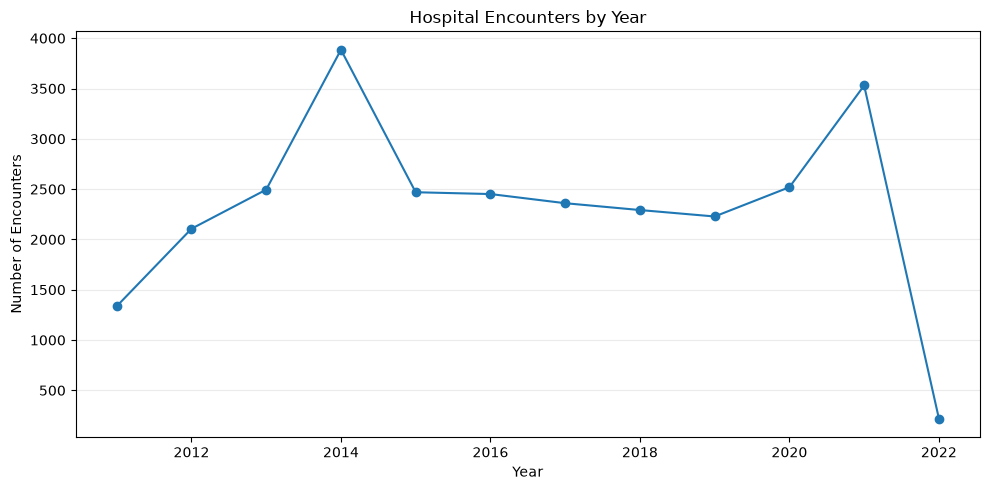

In [23]:
annual_encounters = (
    encounters_full.groupby("year").size().reset_index(name="encounters")
)
display(annual_encounters)

plt.figure(figsize=(10, 5))
plt.plot(annual_encounters["year"], annual_encounters["encounters"], marker="o")
plt.title("Hospital Encounters by Year")
plt.xlabel("Year")
plt.ylabel("Number of Encounters")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation note:** 2022 is a partial year in this dataset and should not be interpreted as a full-year decline.

### 6.2 Encounter-class mix

,ENCOUNTERCLASS,encounters,percentage
0,ambulatory,12537,44.95
3,outpatient,6300,22.59
4,urgentcare,3666,13.14
1,emergency,2322,8.33
5,wellness,1931,6.92
2,inpatient,1135,4.07


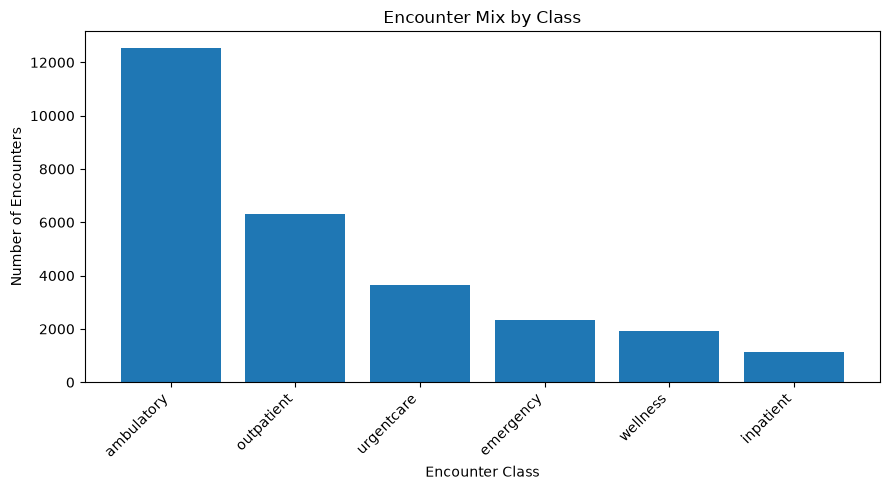

In [24]:
encounter_class_summary = (
    encounters_full.groupby("ENCOUNTERCLASS").size().reset_index(name="encounters")
)
encounter_class_summary["percentage"] = (
    encounter_class_summary["encounters"] / encounter_class_summary["encounters"].sum() * 100
)
encounter_class_summary = encounter_class_summary.sort_values("encounters", ascending=False)
display(encounter_class_summary)

plt.figure(figsize=(9, 5))
plt.bar(encounter_class_summary["ENCOUNTERCLASS"], encounter_class_summary["encounters"])
plt.title("Encounter Mix by Class")
plt.xlabel("Encounter Class")
plt.ylabel("Number of Encounters")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 6.3 Encounter-class trends

ENCOUNTERCLASS,ambulatory,emergency,inpatient,outpatient,urgentcare,wellness
year,,,,,,
2011,667,55,83,327,30,174
2012,895,183,93,444,299,192
2013,1106,225,134,485,359,186
2014,2341,216,118,694,327,189
2015,1073,228,111,506,380,171
2016,1073,250,124,481,341,182
2017,987,218,126,475,385,169
2018,933,247,81,480,377,174
2019,846,227,134,456,397,168


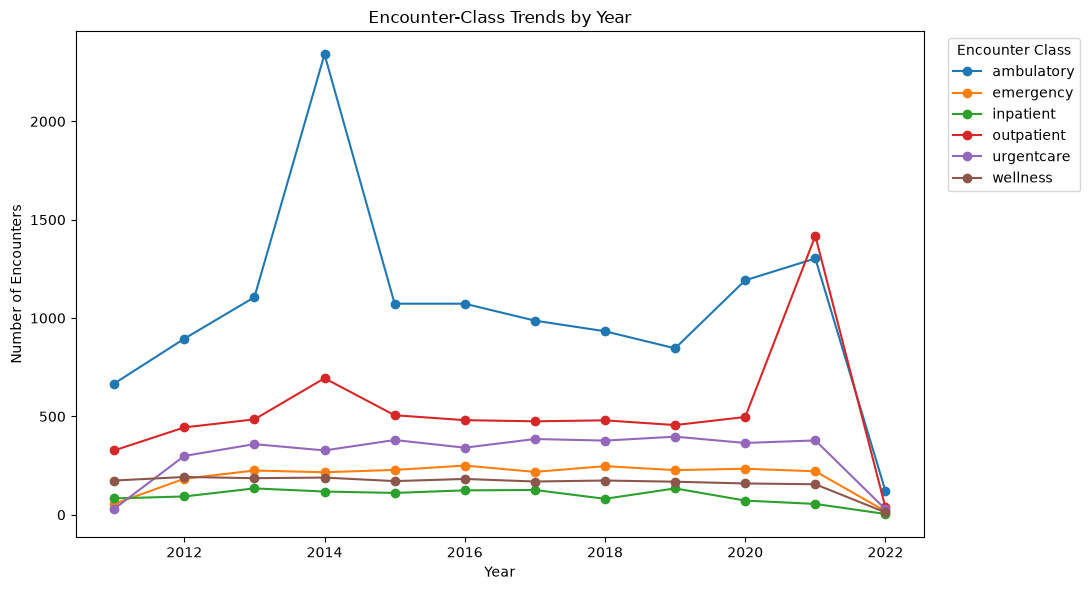

In [25]:
annual_class = (
    encounters_full.groupby(["year", "ENCOUNTERCLASS"]).size()
    .reset_index(name="encounters")
)
annual_class_pivot = annual_class.pivot(index="year", columns="ENCOUNTERCLASS", values="encounters").fillna(0)
display(annual_class_pivot)

plt.figure(figsize=(11, 6))
for col in annual_class_pivot.columns:
    plt.plot(annual_class_pivot.index, annual_class_pivot[col], marker="o", label=col)
plt.title("Encounter-Class Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Encounters")
plt.legend(title="Encounter Class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 6.4 Duration distribution

,duration_hours
count,"27,891.00"
mean,7.27
std,398.32
min,0.25
90%,2.80
95%,3.80
99%,24.00
max,"44,930.00"


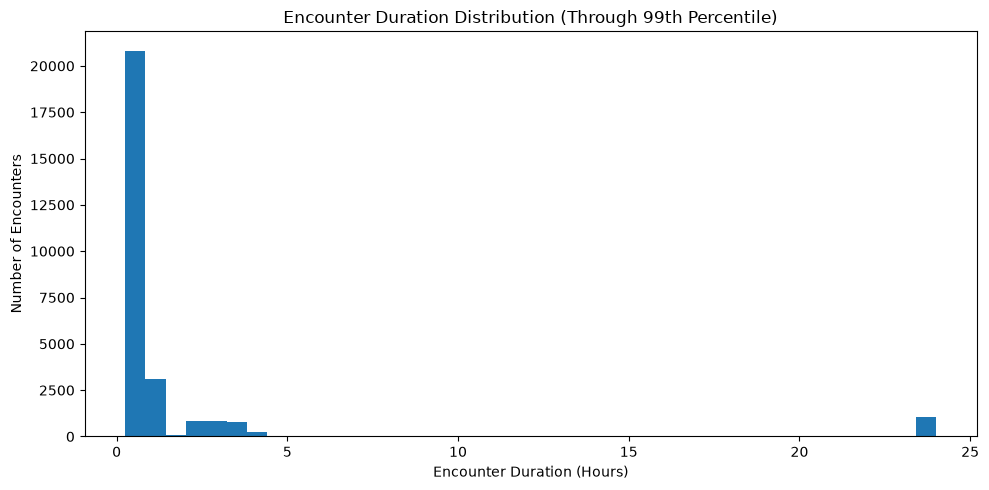

Exactly 24 hours: 1,077
Longer than 24 hours: 75
Maximum duration: 44,930 hours


In [26]:
duration_stats = encounters_full["duration_hours"].describe(percentiles=[0.90, 0.95, 0.99])
display(duration_stats.to_frame("duration_hours"))

p99 = encounters_full["duration_hours"].quantile(0.99)
plot_duration = encounters_full.loc[encounters_full["duration_hours"] <= p99, "duration_hours"]

plt.figure(figsize=(10, 5))
plt.hist(plot_duration, bins=40)
plt.title("Encounter Duration Distribution (Through 99th Percentile)")
plt.xlabel("Encounter Duration (Hours)")
plt.ylabel("Number of Encounters")
plt.tight_layout()
plt.show()

print(f"Exactly 24 hours: {(encounters_full['duration_hours'] == 24).sum():,}")
print(f"Longer than 24 hours: {(encounters_full['duration_hours'] > 24).sum():,}")
print(f"Maximum duration: {encounters_full['duration_hours'].max():,.0f} hours")

### 6.5 Payer coverage

,ENCOUNTERCLASS,encounters,zero_coverage_encounters,zero_coverage_pct
3,outpatient,6300,3302,52.41
0,ambulatory,12537,6503,51.87
2,inpatient,1135,551,48.55
4,urgentcare,3666,1678,45.77
5,wellness,1931,793,41.07
1,emergency,2322,759,32.69


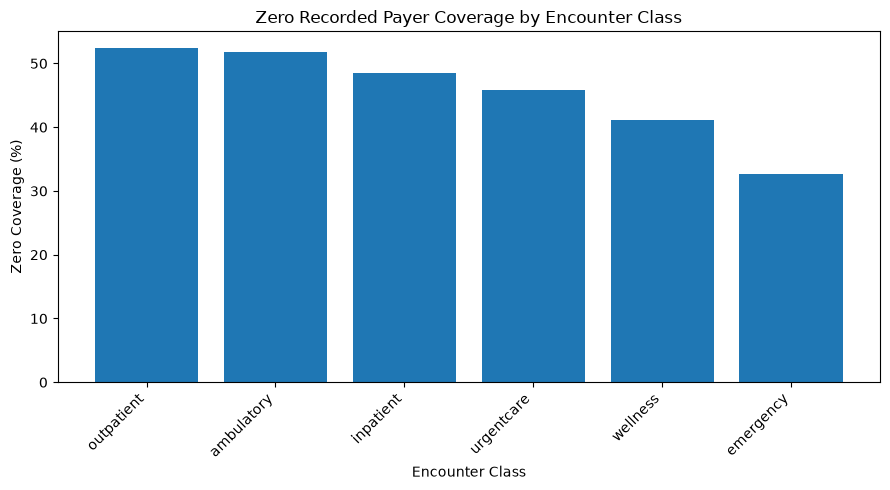

In [27]:
coverage_by_class = (
    encounters_full.groupby("ENCOUNTERCLASS")
    .agg(encounters=("Id", "size"), zero_coverage_encounters=("zero_coverage", "sum"))
    .reset_index()
)
coverage_by_class["zero_coverage_pct"] = (
    coverage_by_class["zero_coverage_encounters"] / coverage_by_class["encounters"] * 100
)
display(coverage_by_class.sort_values("zero_coverage_pct", ascending=False))

plt.figure(figsize=(9, 5))
plot_cov = coverage_by_class.sort_values("zero_coverage_pct", ascending=False)
plt.bar(plot_cov["ENCOUNTERCLASS"], plot_cov["zero_coverage_pct"])
plt.title("Zero Recorded Payer Coverage by Encounter Class")
plt.xlabel("Encounter Class")
plt.ylabel("Zero Coverage (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# 7. Statistical Analysis

### 7.1 Chi-square test: encounter class vs. zero payer coverage

In [28]:
coverage_contingency = pd.crosstab(encounters_full["ENCOUNTERCLASS"], encounters_full["zero_coverage"])
display(coverage_contingency)

chi2, chi_p, dof, expected = chi2_contingency(coverage_contingency)
print(f"Chi-square statistic: {chi2:,.2f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {chi_p:.3e}")

zero_coverage,False,True
ENCOUNTERCLASS,,
ambulatory,6034,6503
emergency,1563,759
inpatient,584,551
outpatient,2998,3302
urgentcare,1988,1678
wellness,1138,793


Chi-square statistic: 381.13
Degrees of freedom: 5
P-value: 3.451e-80


### 7.2 Cramér's V effect size

In [29]:
n = coverage_contingency.to_numpy().sum()
r, k = coverage_contingency.shape
cramers_v = np.sqrt(chi2 / (n * min(r - 1, k - 1)))
print(f"Cramer's V: {cramers_v:.3f}")

Cramer's V: 0.117


### 7.3 Spearman correlation: encounter duration vs. total claim cost

In [30]:
correlation_data = encounters_full[["duration_hours", "TOTAL_CLAIM_COST"]].dropna()
rho, spearman_p = spearmanr(correlation_data["duration_hours"], correlation_data["TOTAL_CLAIM_COST"])
print(f"Spearman rho: {rho:.3f}")
print(f"P-value: {spearman_p:.3e}")

Spearman rho: 0.338
P-value: 0.000e+00


### 7.4 Statistical interpretation

In [31]:
def association_strength(value):
    value = abs(value)
    if value < 0.10:
        return "very weak"
    if value < 0.30:
        return "weak"
    if value < 0.50:
        return "moderate"
    if value < 0.70:
        return "strong"
    return "very strong"

chi_interpretation = "statistically significant" if chi_p < 0.05 else "not statistically significant"
corr_interpretation = "statistically significant" if spearman_p < 0.05 else "not statistically significant"

display(pd.DataFrame({
    "analysis": [
        "Encounter class vs zero recorded payer coverage",
        "Encounter duration vs total claim cost"
    ],
    "method": ["Chi-square + Cramer's V", "Spearman correlation"],
    "statistic": [chi2, rho],
    "p_value": [chi_p, spearman_p],
    "effect_or_strength": [f"Cramer's V = {cramers_v:.3f} ({association_strength(cramers_v)})", f"rho = {rho:.3f} ({association_strength(rho)})"],
    "interpretation": [chi_interpretation, corr_interpretation]
}))

print("Statistical significance indicates association, not causation.")

,analysis,method,statistic,p_value,effect_or_strength,interpretation
0,Encounter class vs zero recorded payer coverage,Chi-square + Cramer's V,381.13,0.00,Cramer's V = 0.117 (weak),statistically significant
1,Encounter duration vs total claim cost,Spearman correlation,0.34,0.00,rho = 0.338 (moderate),statistically significant


Statistical significance indicates association, not causation.


# 8. Healthcare Operations Analysis

### 8.1 Procedure frequency

,DESCRIPTION,procedure_count,average_base_cost,median_base_cost,total_base_cost
11,Assessment of health and social care needs (pr...,4596,431.00,431.00,1980876
69,Hospice care (regime/therapy),4098,431.00,431.00,1766238
46,Depression screening using Patient Health Ques...,3614,431.00,431.00,1557634
44,Depression screening (procedure),3614,431.00,431.00,1557634
12,Assessment of substance use (procedure),2906,431.00,431.00,1252486
124,Renal dialysis (procedure),2746,"1,004.09",978.00,2757221
14,Assessment using Morse Fall Scale (procedure),2422,431.00,431.00,1043882
10,Assessment of anxiety (procedure),2288,431.00,431.00,986128
95,Medication Reconciliation (procedure),2284,509.12,496.00,1162840
132,Screening for drug abuse (procedure),1484,431.00,431.00,639604


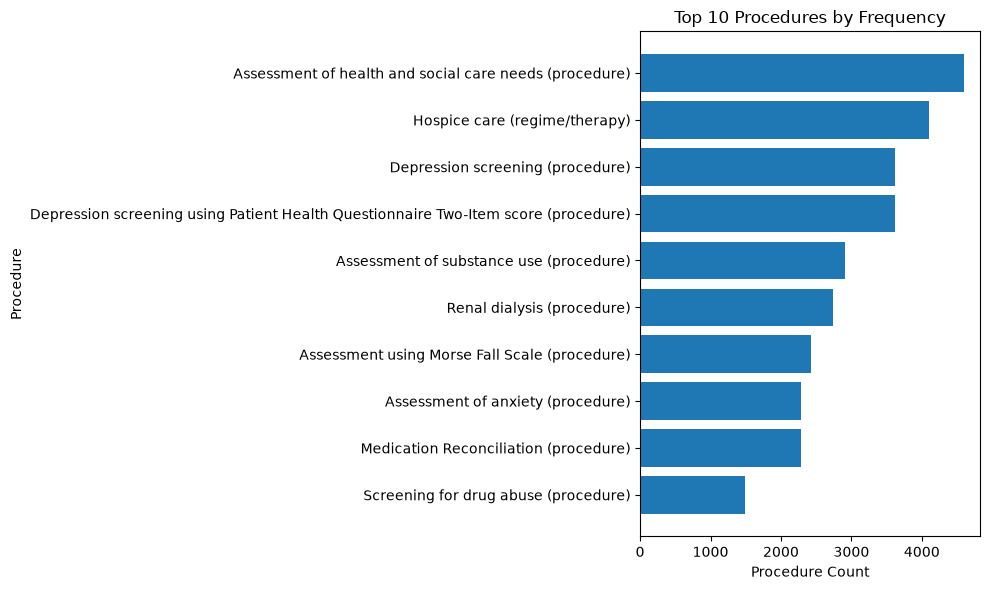

In [32]:
procedure_summary = (
    procedures_clean.groupby("DESCRIPTION")
    .agg(
        procedure_count=("DESCRIPTION", "size"),
        average_base_cost=("BASE_COST", "mean"),
        median_base_cost=("BASE_COST", "median"),
        total_base_cost=("BASE_COST", "sum")
    )
    .reset_index()
)

top_procedures = procedure_summary.sort_values("procedure_count", ascending=False).head(10)
display(top_procedures)

plt.figure(figsize=(10, 6))
plot_df = top_procedures.sort_values("procedure_count")
plt.barh(plot_df["DESCRIPTION"], plot_df["procedure_count"])
plt.title("Top 10 Procedures by Frequency")
plt.xlabel("Procedure Count")
plt.ylabel("Procedure")
plt.tight_layout()
plt.show()

### 8.2 Procedure cost

In [33]:
minimum_procedure_count = 5
highest_cost_procedures = (
    procedure_summary.query("procedure_count >= @minimum_procedure_count")
    .sort_values("average_base_cost", ascending=False)
    .head(10)
)
display(highest_cost_procedures)

print(f"Minimum procedure count used for average-cost ranking: {minimum_procedure_count}")

,DESCRIPTION,procedure_count,average_base_cost,median_base_cost,total_base_cost
4,Admit to ICU (procedure),5,"206,260.40","199,610.00",1031302
39,Coronary artery bypass grafting,9,"47,085.89","43,374.00",423773
86,Lumpectomy of breast (procedure),5,"29,353.00","29,349.00",146765
64,Hemodialysis (procedure),27,"29,299.56","28,314.00",791088
50,Electrical cardioversion,1383,"25,903.11","25,066.00",35824002
103,Partial resection of colon,7,"25,229.29","23,031.00",176605
107,Percutaneous mechanical thrombectomy of portal...,57,"20,228.04","19,073.00",1152998
106,Percutaneous coronary intervention,9,"19,728.00","17,748.00",177552
145,Surgical manipulation of joint of knee,12,"16,320.08","16,759.00",195841
161,Vasectomy,5,"12,106.20","11,304.00",60531


Minimum procedure count used for average-cost ranking: 5


A minimum procedure volume is applied to the average-cost ranking to reduce the influence of extremely small samples. Average cost should still be interpreted together with procedure volume.

### 8.3 Procedure impact matrix

,DESCRIPTION,procedure_count,average_base_cost,total_base_cost
50,Electrical cardioversion,1383,"25,903.11",35824002
17,Auscultation of the fetal heart,1065,"5,312.51",5657822
54,Evaluation of uterine fundal height,1065,"5,287.59",5631281
36,Combined chemotherapy and radiation therapy (p...,444,"11,796.39",5237596
35,Colonoscopy,424,"11,841.99",5021003
27,Catheter ablation of tissue of heart,365,"9,331.50",3405999
124,Renal dialysis (procedure),2746,"1,004.09",2757221
11,Assessment of health and social care needs (pr...,4596,431.00,1980876
23,Bone density scan (procedure),198,"9,602.86",1901367
69,Hospice care (regime/therapy),4098,431.00,1766238


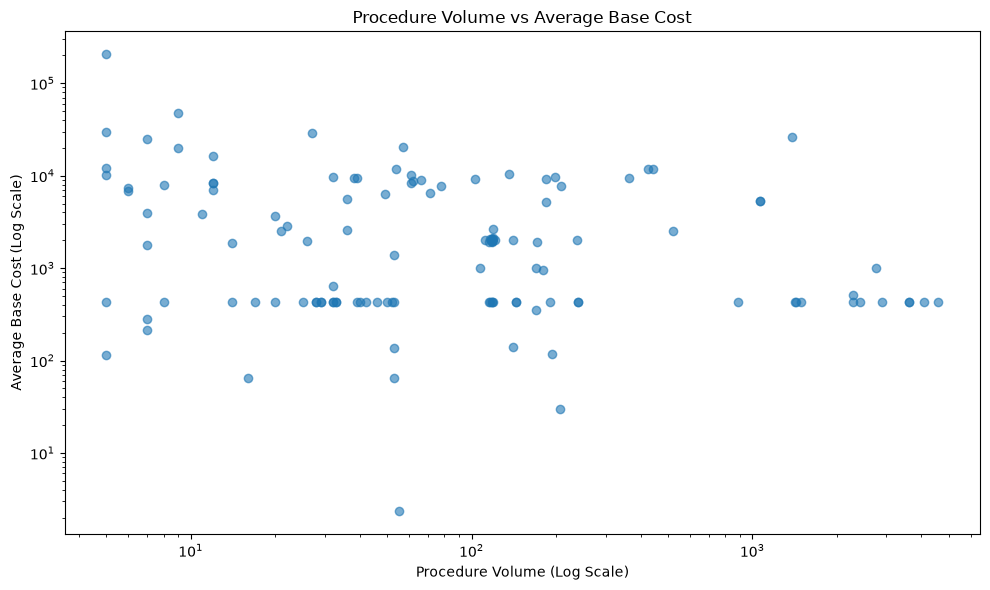

In [34]:
procedure_impact = procedure_summary.copy()
procedure_impact["estimated_cost_impact"] = procedure_impact["total_base_cost"]

procedure_plot = procedure_impact.query("procedure_count >= @minimum_procedure_count").copy()

display(
    procedure_impact.sort_values("estimated_cost_impact", ascending=False)
    [["DESCRIPTION", "procedure_count", "average_base_cost", "total_base_cost"]]
    .head(10)
)

plt.figure(figsize=(10, 6))
plt.scatter(procedure_plot["procedure_count"], procedure_plot["average_base_cost"], alpha=0.6)
plt.xscale("log")
plt.yscale("log")
plt.title("Procedure Volume vs Average Base Cost")
plt.xlabel("Procedure Volume (Log Scale)")
plt.ylabel("Average Base Cost (Log Scale)")
plt.tight_layout()
plt.show()

**Operational use:** Procedures in the high-volume/high-cost portion of the matrix may warrant greater attention than procedures ranked by cost or frequency alone. `total_base_cost` is used as an aggregate procedure cost-impact measure and should not be interpreted as profitability.


### 8.4 Quarterly inpatient utilization

,year_quarter,unique_patients,inpatient_encounters
0,2011Q1,10,21
1,2011Q2,8,18
2,2011Q3,12,24
3,2011Q4,8,20
4,2012Q1,10,20
5,2012Q2,11,21
6,2012Q3,10,22
7,2012Q4,16,30
8,2013Q1,12,22
9,2013Q2,12,21


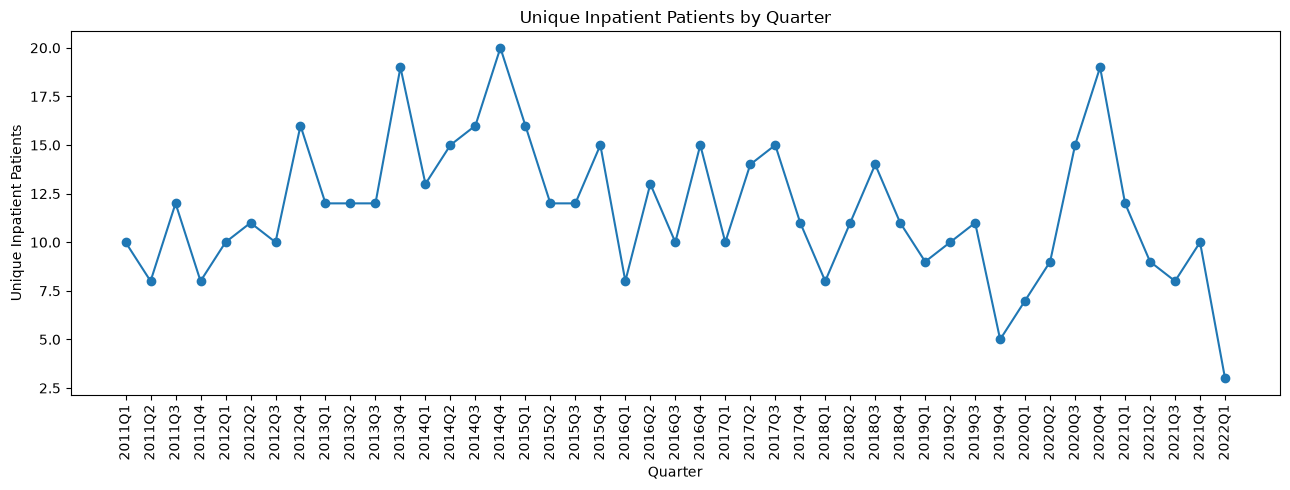

In [35]:
inpatient = encounters_full.loc[encounters_full["ENCOUNTERCLASS"].eq("inpatient")].copy()
quarterly_inpatient = (
    inpatient.groupby("year_quarter")
    .agg(unique_patients=("PATIENT", "nunique"), inpatient_encounters=("Id", "size"))
    .reset_index()
)
display(quarterly_inpatient)

plt.figure(figsize=(13, 5))
plt.plot(quarterly_inpatient["year_quarter"], quarterly_inpatient["unique_patients"], marker="o")
plt.title("Unique Inpatient Patients by Quarter")
plt.xlabel("Quarter")
plt.ylabel("Unique Inpatient Patients")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 8.5 Inpatient length of stay

In [36]:
inpatient_los = pd.Series({
    "mean_hours": inpatient["duration_hours"].mean(),
    "median_hours": inpatient["duration_hours"].median(),
    "p90_hours": inpatient["duration_hours"].quantile(0.90),
    "p95_hours": inpatient["duration_hours"].quantile(0.95),
    "maximum_hours": inpatient["duration_hours"].max()
})
display(inpatient_los.to_frame("value"))

,value
mean_hours,36.84
median_hours,24.00
p90_hours,24.00
p95_hours,24.63
maximum_hours,"8,250.00"


# 9. Cost & Payer Analysis

### 9.1 Average claim cost

In [37]:
payer_summary = (
    encounters_full.groupby("PAYER_NAME")
    .agg(
        encounters=("Id", "size"),
        unique_patients=("PATIENT", "nunique"),
        average_claim_cost=("TOTAL_CLAIM_COST", "mean"),
        median_claim_cost=("TOTAL_CLAIM_COST", "median"),
        total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
        average_payer_coverage=("PAYER_COVERAGE", "mean"),
        median_payer_coverage=("PAYER_COVERAGE", "median"),
        zero_coverage_pct=("zero_coverage", "mean")
    )
    .reset_index()
)
payer_summary["zero_coverage_pct"] *= 100
payer_summary = payer_summary.sort_values("average_claim_cost", ascending=False)
display(payer_summary[["PAYER_NAME", "encounters", "average_claim_cost"]])

,PAYER_NAME,encounters,average_claim_cost
6,Medicaid,1443,"6,205.22"
8,NO_INSURANCE,8807,"5,593.20"
1,Anthem,704,"4,236.81"
5,Humana,1084,"3,269.30"
2,Blue Cross Blue Shield,925,"3,245.58"
3,Cigna Health,809,"2,996.95"
9,UnitedHealthcare,900,"2,848.34"
0,Aetna,936,"2,767.05"
7,Medicare,11371,"2,167.55"
4,Dual Eligible,912,"1,696.19"


### 9.2 Median claim cost

In [38]:
display(
    payer_summary[["PAYER_NAME", "encounters", "median_claim_cost"]]
    .sort_values("median_claim_cost", ascending=False)
)

,PAYER_NAME,encounters,median_claim_cost
6,Medicaid,1443,"1,005.38"
8,NO_INSURANCE,8807,920.81
1,Anthem,704,278.58
5,Humana,1084,278.58
2,Blue Cross Blue Shield,925,278.58
3,Cigna Health,809,278.58
9,UnitedHealthcare,900,278.58
0,Aetna,936,278.58
7,Medicare,11371,234.72
4,Dual Eligible,912,142.58


### 9.3 Payer coverage

,PAYER_NAME,encounters,average_payer_coverage,median_payer_coverage,zero_coverage_pct
8,NO_INSURANCE,8807,0.00,0.00,100.00
1,Anthem,704,0.00,0.00,100.00
3,Cigna Health,809,1.20,0.00,97.65
0,Aetna,936,1.90,0.00,95.94
5,Humana,1084,1.80,0.00,95.76
9,UnitedHealthcare,900,4.37,0.00,91.11
2,Blue Cross Blue Shield,925,"2,242.70",50.69,36.32
4,Dual Eligible,912,"1,513.93",40.45,13.93
7,Medicare,11371,"1,689.89",155.77,0.54
6,Medicaid,1443,"5,833.66",898.11,0.35


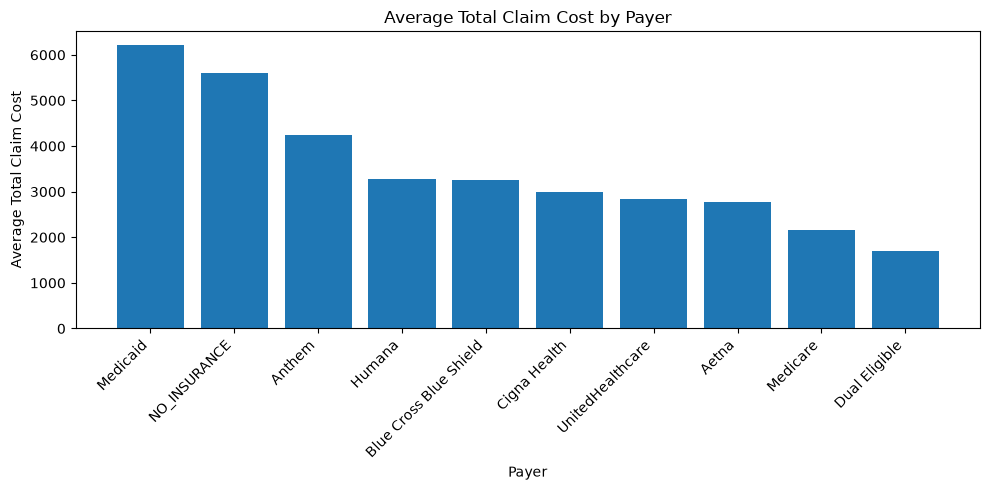

In [39]:
display(
    payer_summary[[
        "PAYER_NAME", "encounters", "average_payer_coverage",
        "median_payer_coverage", "zero_coverage_pct"
    ]].sort_values("zero_coverage_pct", ascending=False)
)

plt.figure(figsize=(10, 5))
plot_payers = payer_summary.sort_values("average_claim_cost", ascending=False)
plt.bar(plot_payers["PAYER_NAME"], plot_payers["average_claim_cost"])
plt.title("Average Total Claim Cost by Payer")
plt.xlabel("Payer")
plt.ylabel("Average Total Claim Cost")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 9.4 Case-mix limitation

In [40]:
payer_class_mix = pd.crosstab(
    encounters_full["PAYER_NAME"],
    encounters_full["ENCOUNTERCLASS"],
    normalize="index"
) * 100

display(payer_class_mix.round(1))

ENCOUNTERCLASS,ambulatory,emergency,inpatient,outpatient,urgentcare,wellness
PAYER_NAME,,,,,,
Aetna,46.40,3.80,4.50,33.10,4.20,8.00
Anthem,44.50,5.00,2.00,37.10,2.10,9.40
Blue Cross Blue Shield,39.40,3.60,3.50,36.60,7.00,9.90
Cigna Health,41.40,4.60,2.80,35.50,3.50,12.20
Dual Eligible,55.80,4.10,6.00,13.60,13.40,7.10
Humana,47.80,4.50,5.80,29.60,4.10,8.20
Medicaid,53.20,6.80,2.10,32.60,1.40,3.90
Medicare,39.00,12.40,4.40,19.80,15.80,8.70
NO_INSURANCE,50.60,6.30,3.80,18.50,17.00,3.80


**Interpretation limitation:** Differences in payer-level average claim cost should **not** be interpreted as payer performance. Encounter class, patient mix, procedure mix, severity, and other clinical factors are not controlled in this descriptive comparison.

# 10. Patient Utilization Analysis

### 10.1 30-day repeat encounters

In [41]:
total_repeat_events = int(encounters_full["repeat_30_day"].sum())
patients_with_repeat = encounters_full.loc[encounters_full["repeat_30_day"], "PATIENT"].nunique()
total_patients = encounters_full["PATIENT"].nunique()

repeat_summary = pd.DataFrame({
    "metric": [
        "Unique patients",
        "30-day repeat encounter events",
        "Unique patients with at least one 30-day repeat",
        "Patients with repeat (%)"
    ],
    "value": [
        total_patients,
        total_repeat_events,
        patients_with_repeat,
        patients_with_repeat / total_patients * 100
    ]
})
display(repeat_summary)

,metric,value
0,Unique patients,974.00
1,30-day repeat encounter events,"17,262.00"
2,Unique patients with at least one 30-day repeat,772.00
3,Patients with repeat (%),79.26


**Definition:** A 30-day repeat encounter is an encounter occurring within 0–30 days of the immediately preceding encounter for the same patient. This is a project-defined utilization measure and **not** a formal clinical 30-day readmission rate.


### 10.2 Unique patients with repeats by age group

,age_group,unique_patients,patients_with_repeat,repeat_events,patients_with_repeat_pct
0,18-34,140,102,1379,72.86
1,35-49,249,174,1493,69.88
2,50-64,267,188,1571,70.41
3,65-79,316,229,2590,72.47
4,80+,365,289,10229,79.18


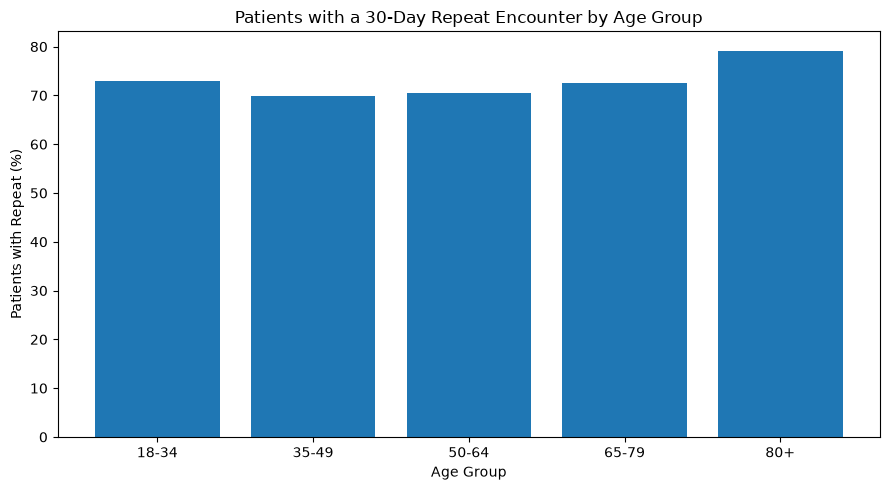

In [42]:
repeat_patient_age = (
    encounters_full.groupby(["PATIENT", "age_group"], observed=True)
    .agg(repeat_30_day_events=("repeat_30_day", "sum"), total_encounters=("Id", "size"))
    .reset_index()
)
repeat_patient_age["has_repeat"] = repeat_patient_age["repeat_30_day_events"] > 0

repeat_by_age = (
    repeat_patient_age.groupby("age_group", observed=True)
    .agg(
        unique_patients=("PATIENT", "nunique"),
        patients_with_repeat=("has_repeat", "sum"),
        repeat_events=("repeat_30_day_events", "sum")
    )
    .reset_index()
)
repeat_by_age["patients_with_repeat_pct"] = (
    repeat_by_age["patients_with_repeat"] / repeat_by_age["unique_patients"] * 100
)
display(repeat_by_age)

plt.figure(figsize=(9, 5))
plt.bar(repeat_by_age["age_group"].astype(str), repeat_by_age["patients_with_repeat_pct"])
plt.title("Patients with a 30-Day Repeat Encounter by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Patients with Repeat (%)")
plt.tight_layout()
plt.show()

### 10.3 High-utilization patients

In [43]:
patient_utilization = (
    encounters_full.groupby("PATIENT")
    .agg(
        total_encounters=("Id", "size"),
        repeat_30_day_events=("repeat_30_day", "sum"),
        total_claim_cost=("TOTAL_CLAIM_COST", "sum"),
        average_claim_cost=("TOTAL_CLAIM_COST", "mean"),
        first_encounter=("START", "min"),
        last_encounter=("START", "max")
    )
    .reset_index()
)

high_utilization_threshold = patient_utilization["total_encounters"].quantile(0.90)
patient_utilization["high_utilizer"] = patient_utilization["total_encounters"] >= high_utilization_threshold

print(f"90th percentile encounter threshold: {high_utilization_threshold:.1f}")
print(f"Patients flagged as high utilizers: {patient_utilization['high_utilizer'].sum():,}")

display(
    patient_utilization.sort_values(
        ["total_encounters", "repeat_30_day_events"], ascending=False
    ).head(10)
)

90th percentile encounter threshold: 54.7
Patients flagged as high utilizers: 98


,PATIENT,total_encounters,repeat_30_day_events,total_claim_cost,average_claim_cost,first_encounter,last_encounter,high_utilizer
85,1712d26d-822d-1e3a-2267-0a9dba31d7c8,1381,1376,"2,437,415.31","1,764.96",2011-01-15 02:30:15+00:00,2022-01-23 06:12:15+00:00,True
371,5e055638-0dad-dfd5-005d-1e74b6fd29ac,887,871,"844,913.74",952.55,2011-02-19 21:52:02+00:00,2022-01-22 14:10:02+00:00,True
240,3de74169-7f67-9304-91d4-757e0f3a14d2,877,876,"819,279.19",934.18,2011-01-02 09:26:36+00:00,2017-02-11 14:47:36+00:00,True
245,3f523789-55f3-bb31-2757-4803ca6a9c2a,447,442,"9,932,262.99","22,219.83",2011-03-16 16:58:48+00:00,2022-01-26 16:58:48+00:00,True
370,5dcb295d-92df-a147-ebcc-aa49b6262830,441,421,"105,080.78",238.28,2011-03-09 00:07:50+00:00,2022-01-21 02:59:21+00:00,True
275,442dc617-c7f2-0513-15cd-c35c4efdba73,392,384,"156,858.67",400.15,2011-01-26 02:54:11+00:00,2022-01-19 02:54:11+00:00,True
694,b4ab9ab3-f52a-751e-a990-3bd5654d5870,383,376,"124,858.48",326.00,2011-01-26 08:24:25+00:00,2022-01-26 08:24:25+00:00,True
600,9b8ae606-5059-b3a6-19c7-c812901898bb,364,347,"187,907.26",516.23,2011-01-16 05:11:07+00:00,2022-01-21 08:42:07+00:00,True
693,b4671e80-7e87-9260-ca31-6a9397d465d1,296,291,"65,245.84",220.43,2011-02-28 22:04:02+00:00,2022-01-24 22:04:02+00:00,True
973,ff331e5c-ab16-e218-f39a-63e11de1ed75,291,280,"6,356,665.66","21,844.21",2011-01-10 07:09:49+00:00,2022-01-10 07:09:49+00:00,True


**Definition:** High-utilization patients are defined here as patients at or above the 90th percentile of total encounter count. This threshold is analytical and should be adapted to organizational policy in a real healthcare setting.

# 11. Findings

Each finding is reported as **Finding → Evidence → Business implication**. The values below are generated from the current data so they remain consistent with the notebook results.

In [44]:
annual_2011 = int(annual_encounters.loc[annual_encounters["year"].eq(2011), "encounters"].iloc[0])
annual_2021 = int(annual_encounters.loc[annual_encounters["year"].eq(2021), "encounters"].iloc[0])
growth_2011_2021 = (annual_2021 / annual_2011 - 1) * 100

top_class = encounter_class_summary.iloc[0]
zero_cov_count = int(encounters_full["zero_coverage"].sum())
zero_cov_pct = encounters_full["zero_coverage"].mean() * 100
median_duration = encounters_full["duration_hours"].median()
p95_duration = encounters_full["duration_hours"].quantile(0.95)
max_duration = encounters_full["duration_hours"].max()
top_payer = payer_summary.iloc[0]
top_proc = top_procedures.iloc[0]

findings = pd.DataFrame([
    {
        "Finding": "Encounter volume increased materially between 2011 and 2021.",
        "Evidence": f"{annual_2011:,} encounters in 2011 vs {annual_2021:,} in 2021 ({growth_2011_2021:.1f}% increase).",
        "Business implication": "Capacity and staffing analysis should focus on the service lines contributing to growth rather than relying only on total volume."
    },
    {
        "Finding": "Ambulatory care is the largest encounter class.",
        "Evidence": f"{top_class['ENCOUNTERCLASS']} accounts for {int(top_class['encounters']):,} encounters ({top_class['percentage']:.1f}%).",
        "Business implication": "Operational improvement efforts should consider the dominant ambulatory workload while retaining separate views for inpatient and emergency activity."
    },
    {
        "Finding": "Encounter duration is strongly right-skewed.",
        "Evidence": f"Median = {median_duration:.2f} hours; P95 = {p95_duration:.2f} hours; maximum = {max_duration:,.0f} hours.",
        "Business implication": "Median and percentile measures are more representative than the mean for routine duration monitoring; extreme durations should be investigated separately."
    },
    {
        "Finding": "Zero recorded payer coverage is common and varies by encounter class.",
        "Evidence": f"{zero_cov_count:,} encounters ({zero_cov_pct:.1f}%) have zero recorded coverage; chi-square = {chi2:.2f}, p = {chi_p:.2e}, Cramer's V = {cramers_v:.3f}.",
        "Business implication": "Coverage completeness and payer workflows warrant further review, but zero coverage should not automatically be interpreted as uninsured status."
    },
    {
        "Finding": "Repeat utilization is widespread under the project-defined 30-day metric.",
        "Evidence": f"{total_repeat_events:,} repeat events across {patients_with_repeat:,} unique patients.",
        "Business implication": "Patient-level utilization segmentation can identify groups for deeper investigation, but the metric is not a clinical readmission rate."
    },
    {
        "Finding": "Procedure volume and cost identify different priorities.",
        "Evidence": f"The most frequent procedure is '{top_proc['DESCRIPTION']}' with {int(top_proc['procedure_count']):,} records; cost rankings use a minimum count of {minimum_procedure_count}.",
        "Business implication": "Procedure prioritization should combine frequency and cost impact rather than optimize on either measure alone."
    },
    {
        "Finding": "Average claim cost differs substantially across payers.",
        "Evidence": f"The highest descriptive average in this dataset is {top_payer['PAYER_NAME']} at ${top_payer['average_claim_cost']:,.0f} per encounter.",
        "Business implication": "Payer comparisons require case-mix adjustment before any performance conclusion is made."
    }
])
display(findings)

,Finding,Evidence,Business implication
0,Encounter volume increased materially between ...,"1,336 encounters in 2011 vs 3,530 in 2021 (164...",Capacity and staffing analysis should focus on...
1,Ambulatory care is the largest encounter class.,"ambulatory accounts for 12,537 encounters (44....",Operational improvement efforts should conside...
2,Encounter duration is strongly right-skewed.,Median = 0.25 hours; P95 = 3.80 hours; maximum...,Median and percentile measures are more repres...
3,Zero recorded payer coverage is common and var...,"13,586 encounters (48.7%) have zero recorded c...",Coverage completeness and payer workflows warr...
4,Repeat utilization is widespread under the pro...,"17,262 repeat events across 772 unique patients.",Patient-level utilization segmentation can ide...
5,Procedure volume and cost identify different p...,The most frequent procedure is 'Assessment of ...,Procedure prioritization should combine freque...
6,Average claim cost differs substantially acros...,The highest descriptive average in this datase...,Payer comparisons require case-mix adjustment ...


# 12. Recommendations

The following recommendations are intended to support healthcare leaders and operational decision-makers in using the analytical findings for monitoring, planning, and performance improvement.

1. **Strengthen monitoring of payer coverage.** Establish routine monitoring of encounters with zero recorded payer coverage and review patterns by encounter class, payer, and reporting period. Because zero recorded coverage does not necessarily indicate uninsured status, distinguish between self-pay or no-insurance scenarios, plan-design effects, incomplete data capture, and other administrative conditions before using this measure for financial or operational decisions.

2. **Monitor utilization by encounter class.** Track ambulatory, inpatient, emergency, outpatient, urgent-care, and wellness activity separately. Changes in total encounter volume should be evaluated alongside changes in service mix so that staffing, capacity, and resource-planning decisions reflect where utilization is occurring.

3. **Use median and percentile measures for encounter duration.** Include **median, P90, and P95 encounter duration** in operational reporting rather than relying on the mean alone. Extreme-duration encounters should be monitored separately so unusual records do not distort measures intended to represent typical operational performance.

4. **Monitor frequent repeat utilization.** Include 30-day repeat utilization in routine utilization monitoring to identify patients or patient groups with frequent repeat encounters. These patterns can help leaders identify areas where care coordination, follow-up processes, access to appropriate services, or resource planning may warrant additional attention. The 30-day repeat measure should be treated as a utilization indicator and not as a formal clinical readmission rate.

5. **Use both procedure volume and cost in resource planning.** Evaluate procedure activity using both utilization volume and financial impact. High-volume procedures may represent opportunities for workflow and efficiency improvements, while higher-cost procedures may require closer financial and resource planning. Average-cost comparisons should use appropriate minimum-volume thresholds to avoid decisions based on very small samples.

6. **Use caution when comparing payer costs.** Do not use unadjusted average claim costs as direct measures of payer performance. Cost differences should be interpreted in the context of encounter class, patient characteristics, procedure mix, severity, and other case-mix factors. Where payer comparisons influence strategic or financial decisions, case-mix-adjusted analysis should be used.

### Suggested Executive KPIs

Healthcare leaders may consider incorporating the following measures into operational dashboards and recurring performance reviews:

- Encounter volume and encounter-class mix
- Quarterly inpatient utilization
- Median, P90, and P95 encounter duration
- Percentage of encounters with zero recorded payer coverage
- 30-day repeat-utilization measures
- Procedure volume and cost impact
- Payer claim-cost distributions

Together, these measures provide a balanced view of healthcare utilization, operational activity, data quality, and financial patterns.


# 13. Limitations

- The dataset contains synthetic healthcare records and should not be used for clinical decision-making or evaluation of real healthcare organizations, patients, or payers.
- The encounter data end in early February 2022, so 2022 represents only a partial year and should not be compared directly with prior full calendar years.
- The 30-day repeat encounter measure is project-defined and should not be interpreted as a formal hospital readmission rate.
- Encounter duration contains extreme observations. These records were retained and described rather than automatically removed.
- `PAYER_COVERAGE == 0` represents an observed field value and does not by itself establish uninsured status.
- Statistical tests identify associations and do not establish causation.
- Payer-level cost comparisons are descriptive and are not adjusted for case mix, severity, procedure mix, or other clinical factors.
- Procedure `BASE_COST` and encounter `TOTAL_CLAIM_COST` represent different cost constructs and should not be treated as interchangeable.
- Demographic analysis is descriptive and does not establish healthcare disparities, inequities, or causal differences between groups.
- Available fields limit the operational and clinical questions that can be evaluated.


# 14. Next Phase Analysis

Potential extensions of this analysis include:

1. Monthly and quarterly encounter forecasting.
2. Case-mix-adjusted payer cost modeling.
3. Encounter-class-specific repeat-utilization analysis.
4. Patient demographic and geographic utilization analysis using appropriate denominator controls.
5. Procedure cost-impact analysis by encounter class and payer.
6. Validation of extreme-duration records using related encounter and procedure information.
7. Formal inpatient readmission logic if appropriate admission/discharge definitions and qualifying encounter rules are available.
8. Development of a Power BI dashboard or executive scorecard using the validated analytical outputs.


# 15. Conclusion

In [45]:
summary_metrics = pd.DataFrame({
    "metric": [
        "Total encounters",
        "Unique patients",
        "Procedure records",
        "Zero recorded coverage encounters",
        "Zero recorded coverage (%)",
        "Median encounter duration (hours)",
        "30-day repeat events",
        "Patients with at least one 30-day repeat",
        "Chi-square p-value",
        "Cramer's V",
        "Spearman rho"
    ],
    "value": [
        len(encounters_full),
        encounters_full["PATIENT"].nunique(),
        len(procedures_clean),
        zero_cov_count,
        zero_cov_pct,
        median_duration,
        total_repeat_events,
        patients_with_repeat,
        chi_p,
        cramers_v,
        rho
    ]
})
display(summary_metrics)

,metric,value
0,Total encounters,"27,891.00"
1,Unique patients,974.00
2,Procedure records,"47,701.00"
3,Zero recorded coverage encounters,"13,586.00"
4,Zero recorded coverage (%),48.71
5,Median encounter duration (hours),0.25
6,30-day repeat events,"17,262.00"
7,Patients with at least one 30-day repeat,772.00
8,Chi-square p-value,0.00
9,Cramer's V,0.12


This analysis follows an end-to-end healthcare analytics workflow:

**data understanding → data-quality assessment → cleaning and transformation → exploratory analysis → statistical testing → operational and financial analysis → business interpretation**

The analysis identifies material growth in encounter utilization, a highly skewed encounter-duration distribution, substantial zero recorded payer coverage, frequent repeat utilization, and meaningful variation in procedure and payer cost measures.

The results also demonstrate why healthcare operational metrics require appropriate context. Extreme values, incomplete periods, payer case mix, and project-defined utilization measures can materially affect interpretation and should be considered before analytical results are used to support decisions.


# 16. Export Analytical Results

In [46]:
RESULTS_DIR = Path("../results").resolve()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

annual_encounters.to_csv(
    RESULTS_DIR / "annual_encounters.csv",
    index=False
)

encounter_class_summary.to_csv(
    RESULTS_DIR / "encounter_class_summary.csv",
    index=False
)

coverage_by_class.to_csv(
    RESULTS_DIR / "coverage_by_class.csv",
    index=False
)

quarterly_inpatient.to_csv(
    RESULTS_DIR / "quarterly_inpatient_patients.csv",
    index=False
)

payer_summary.to_csv(
    RESULTS_DIR / "payer_summary.csv",
    index=False
)

procedure_summary.to_csv(
    RESULTS_DIR / "procedure_summary.csv",
    index=False
)

patient_utilization.to_csv(
    RESULTS_DIR / "patient_utilization.csv",
    index=False
)

data_quality_summary.to_csv(
    RESULTS_DIR / "data_quality_summary.csv",
    index=False
)

statistical_results = pd.DataFrame({
    "analysis": [
        "Encounter class vs zero recorded payer coverage",
        "Encounter duration vs total claim cost"
    ],
    "method": [
        "Chi-square + Cramer's V",
        "Spearman correlation"
    ],
    "statistic": [
        chi2,
        rho
    ],
    "p_value": [
        chi_p,
        spearman_p
    ],
    "effect_size": [
        cramers_v,
        abs(rho)
    ]
})

statistical_results.to_csv(
    RESULTS_DIR / "statistical_results.csv",
    index=False
)

print(f"Results exported to: results/")


Results exported to: results/


# 17. Export Figures

In [47]:
FIGURES_DIR = Path("../figures").resolve()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

SAVEFIG_KWARGS = {
    "dpi": 300,
    "bbox_inches": "tight",
    "facecolor": "white"
}

print(f"Figures will be exported to: results/")

Figures will be exported to: results/


### 17.1 Annual Encounter Volume

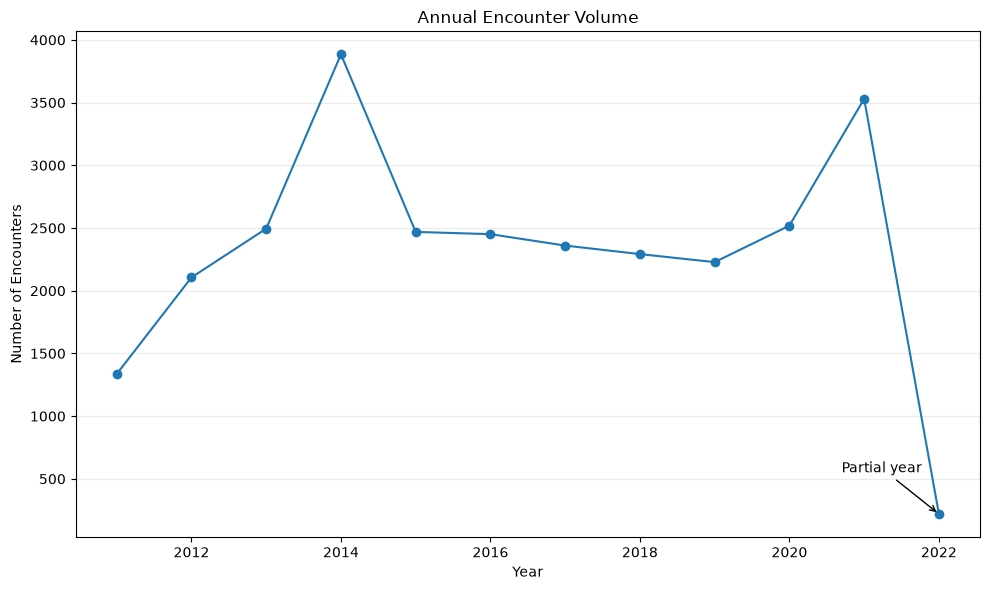

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    annual_encounters["year"],
    annual_encounters["encounters"],
    marker="o"
)

ax.set_title("Annual Encounter Volume")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Encounters")
ax.grid(axis="y", alpha=0.25)

if 2022 in annual_encounters["year"].values:
    encounters_2022 = annual_encounters.loc[
        annual_encounters["year"].eq(2022),
        "encounters"
    ].iloc[0]

    ax.annotate(
        "Partial year",
        xy=(2022, encounters_2022),
        xytext=(-70, 30),
        textcoords="offset points",
        arrowprops={"arrowstyle": "->"}
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "annual_encounter_volume.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.2 Encounter Class Distribution

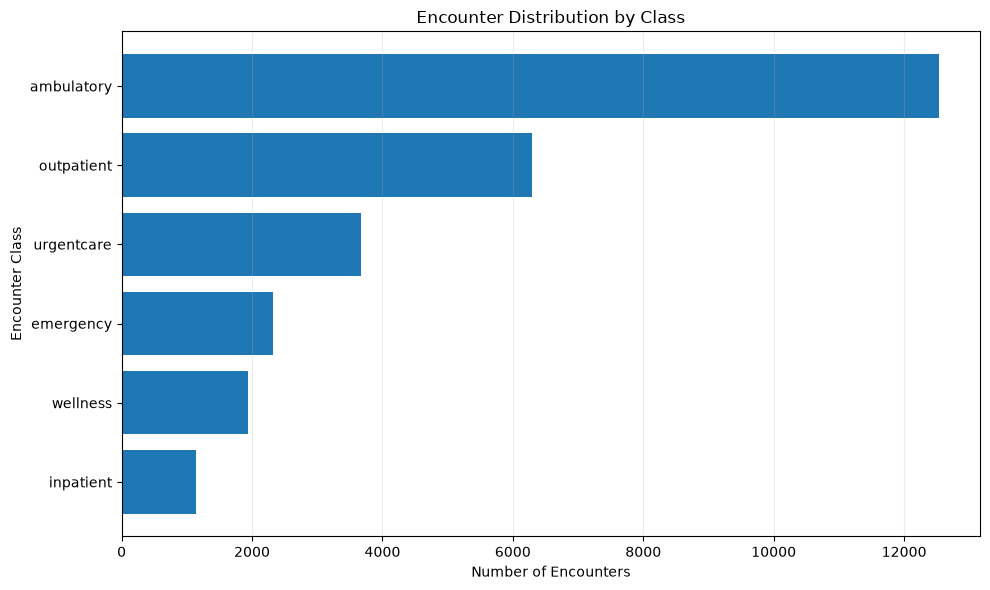

In [49]:
plot_df = encounter_class_summary.sort_values("encounters")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_df["ENCOUNTERCLASS"],
    plot_df["encounters"]
)

ax.set_title("Encounter Distribution by Class")
ax.set_xlabel("Number of Encounters")
ax.set_ylabel("Encounter Class")
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "encounter_class_distribution.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.3 Encounter Duration Distribution

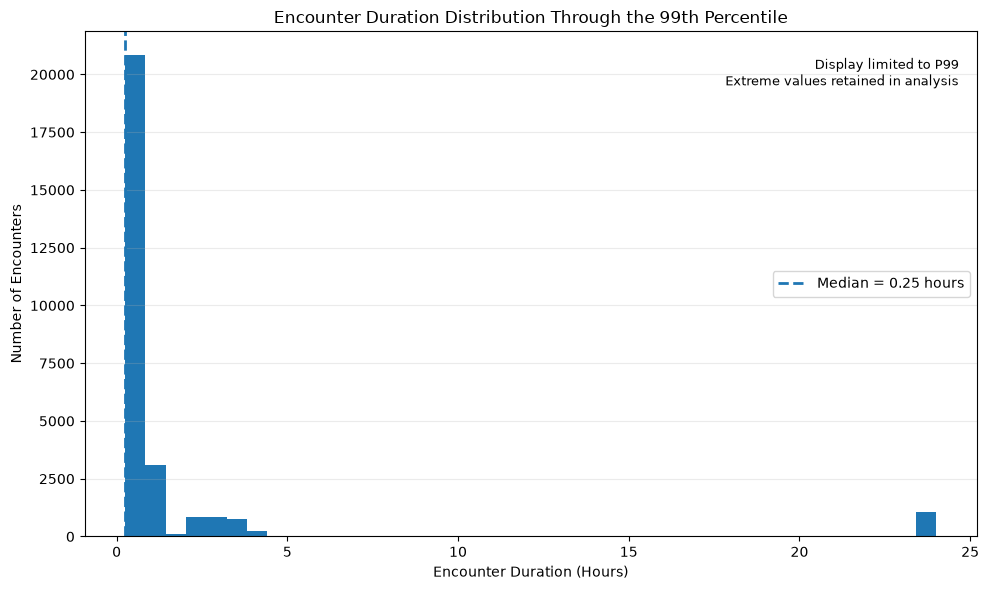

In [50]:
duration = encounters_full["duration_hours"].dropna()

p99_duration = duration.quantile(0.99)
duration_display = duration[duration <= p99_duration]

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    duration_display,
    bins=40
)

median_duration = duration.median()

ax.axvline(
    median_duration,
    linestyle="--",
    linewidth=2,
    label=f"Median = {median_duration:.2f} hours"
)

ax.set_title("Encounter Duration Distribution Through the 99th Percentile")
ax.set_xlabel("Encounter Duration (Hours)")
ax.set_ylabel("Number of Encounters")
ax.legend()
ax.grid(axis="y", alpha=0.25)

ax.text(
    0.98,
    0.95,
    "Display limited to P99\nExtreme values retained in analysis",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "encounter_duration_distribution.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.4 Zero Recorded Payer Coverage

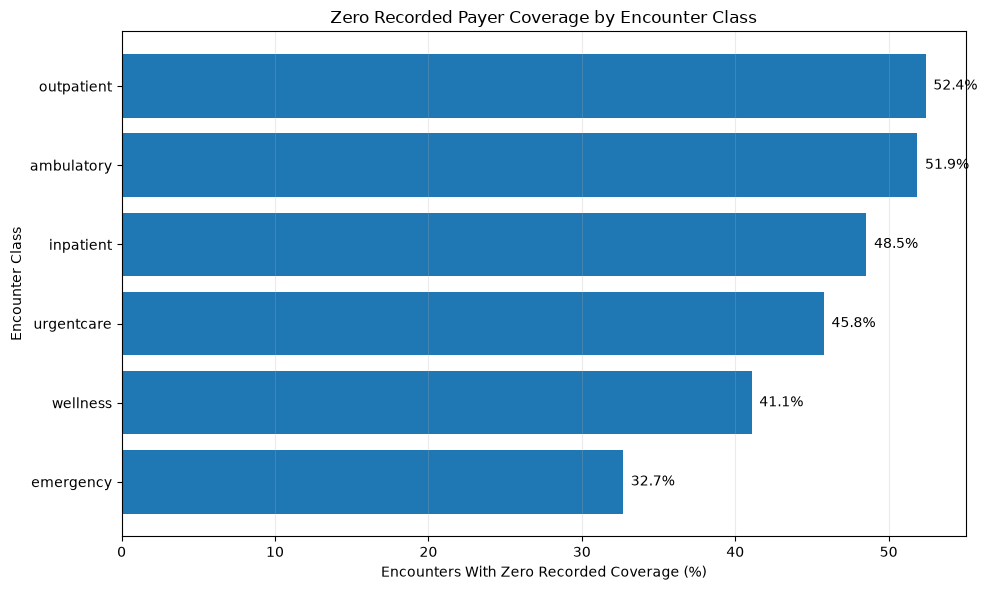

In [51]:
plot_cov = coverage_by_class.sort_values("zero_coverage_pct")

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    plot_cov["ENCOUNTERCLASS"],
    plot_cov["zero_coverage_pct"]
)

ax.set_title("Zero Recorded Payer Coverage by Encounter Class")
ax.set_xlabel("Encounters With Zero Recorded Coverage (%)")
ax.set_ylabel("Encounter Class")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(plot_cov["zero_coverage_pct"]):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "zero_coverage_by_encounter_class.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.5 Quarterly Inpatient Utilization

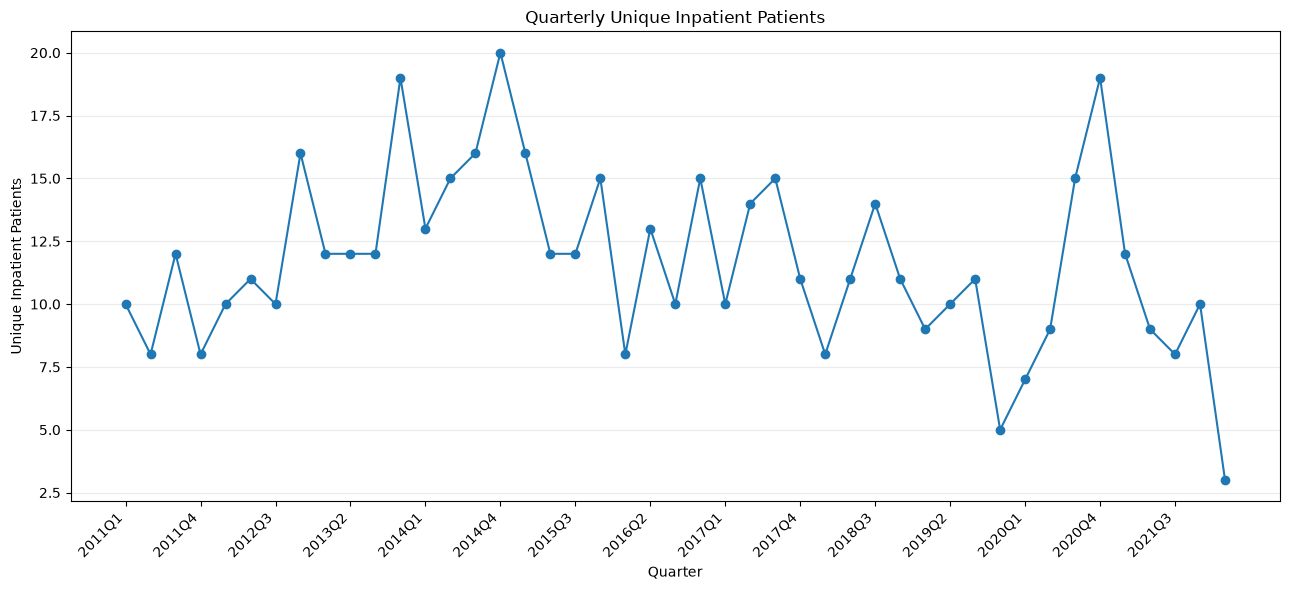

In [52]:
quarterly_plot = quarterly_inpatient.copy()

fig, ax = plt.subplots(figsize=(13, 6))

ax.plot(
    quarterly_plot["year_quarter"],
    quarterly_plot["unique_patients"],
    marker="o"
)

ax.set_title("Quarterly Unique Inpatient Patients")
ax.set_xlabel("Quarter")
ax.set_ylabel("Unique Inpatient Patients")
ax.grid(axis="y", alpha=0.25)

step = max(1, len(quarterly_plot) // 12)
tick_positions = np.arange(0, len(quarterly_plot), step)

ax.set_xticks(tick_positions)
ax.set_xticklabels(
    quarterly_plot["year_quarter"].iloc[tick_positions],
    rotation=45,
    ha="right"
)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "quarterly_inpatient_utilization.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.6 Procedure Volume vs. Average Base Cost

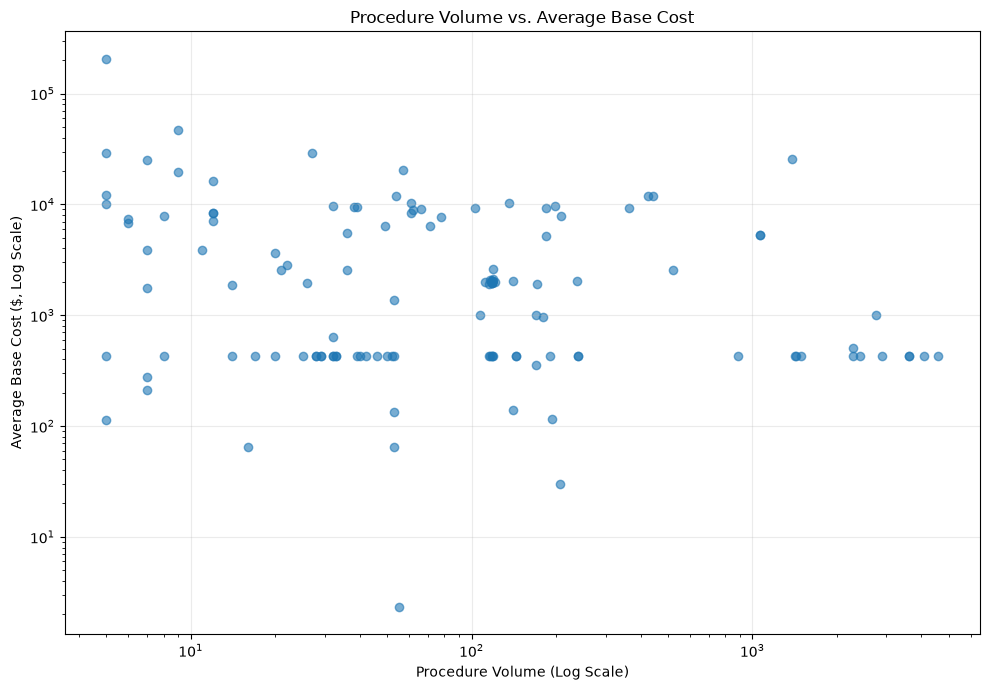

In [53]:
procedure_plot = procedure_summary.loc[
    procedure_summary["procedure_count"] >= minimum_procedure_count
].copy()

fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(
    procedure_plot["procedure_count"],
    procedure_plot["average_base_cost"],
    alpha=0.6
)

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Procedure Volume vs. Average Base Cost")
ax.set_xlabel("Procedure Volume (Log Scale)")
ax.set_ylabel("Average Base Cost ($, Log Scale)")
ax.grid(alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "procedure_volume_vs_cost.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.7 Average Claim Cost by Payer

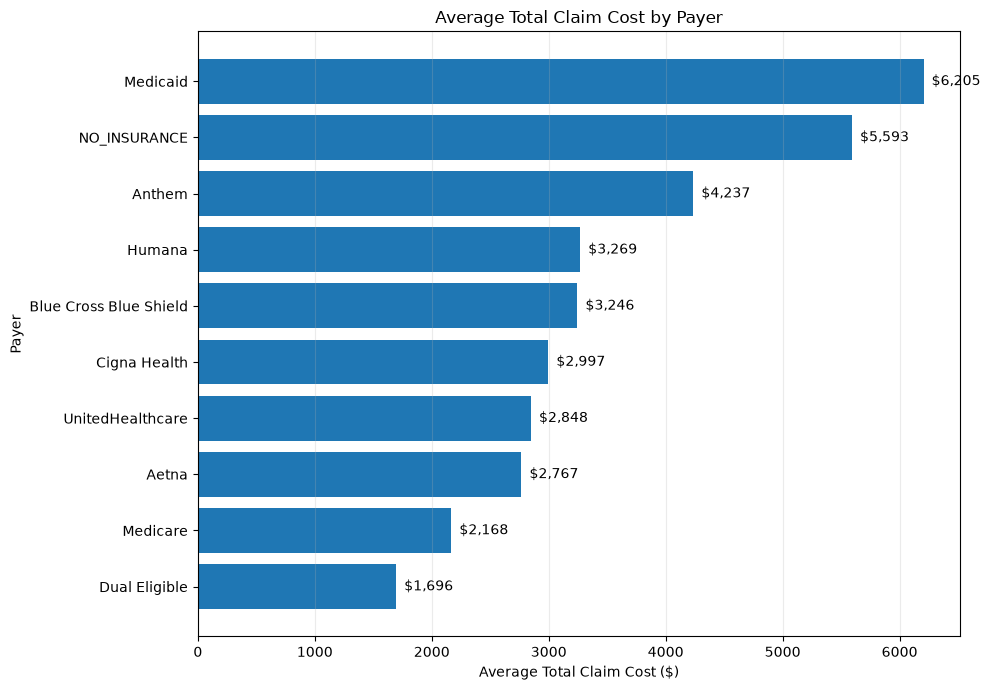

In [ ]:
payer_plot = payer_summary.sort_values("average_claim_cost")

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(
    payer_plot["PAYER_NAME"],
    payer_plot["average_claim_cost"]
)

ax.set_title("Average Total Claim Cost by Payer")
ax.set_xlabel("Average Total Claim Cost ($)") 
ax.set_ylabel("Payer")
ax.grid(axis="x", alpha=0.25)

for i, value in enumerate(payer_plot["average_claim_cost"]):
    ax.text(
        value,
        i,
        f"  ${value:,.0f}",
        va="center"
    )

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "payer_claim_cost_comparison.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

### 17.8 Repeat Utilization by Age Group

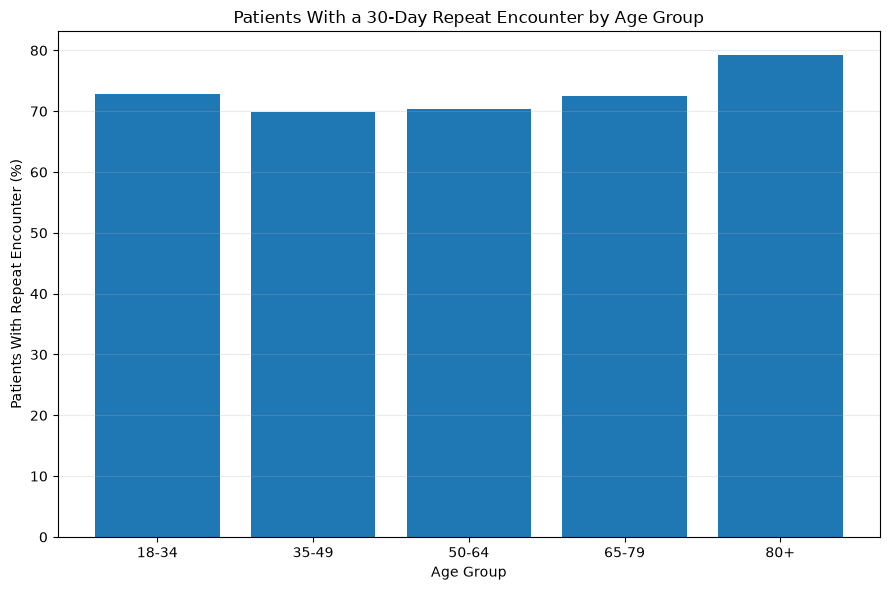

Figures exported to: figures/


In [55]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.bar(
    repeat_by_age["age_group"].astype(str),
    repeat_by_age["patients_with_repeat_pct"]
)

ax.set_title("Patients With a 30-Day Repeat Encounter by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Patients With Repeat Encounter (%)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "repeat_utilization_by_age_group.png",
    **SAVEFIG_KWARGS
)
plt.show()
plt.close(fig)

print(f"Figures exported to: figures/")
